In [ ]:
Homework 1
Peter Iascone
662008393

In [ ]:
Question 1
(a) There are 5 features in x1 and 4 in x2
(b) The L1 norm is 26 for x1 and 98 for x2. The L2 norm is 13.19 for x1 and 89.16 for x2. The L infinity norm is 9 for x1 and 89 for x2

In [ ]:
Question 2
(a) 1024x1024x3 = 3145728
(b) 64x64x3 = 12288
(c) W has 3145728 columns and 12288 rows for a total number of entries of 3.87 x 10^10. b has 12288 elements.

In [ ]:
Question 3
The 1-norm is max(3,-1) = 3. The 2-norm is sqrt(lambda_max*(W^T*W)) = sqrt(3+sqrt(5)) = 2.29.
The infinity norm is the max of the sum of the rows which is 2.
The Frobenius norm of W is sqrt(1^2+1^2+2^2+0^2) = sqrt(6) = 2.449

In [1]:
#Question 4

from sklearn import datasets
iris = datasets.load_iris()
iris.feature_names
iris.target_names
iris.target
X = iris.data[:, :3] # choose 3 out of the 4 features
y = iris.target
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(
    X,y,
    test_size=0.40,
    train_size=0.60,
    random_state=123,
    shuffle=True,
    stratify=y)
from sklearn import svm

clf = svm.SVC()
clf.fit(X_train, y_train)
preds = clf.predict(X_test)
print(preds)
print('actual iris species')
print(y_test)
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test,clf.predict(X_test) )
print('accuracy score :', acc)


[1 1 1 1 0 2 2 0 0 2 0 2 2 1 2 0 1 2 0 2 2 0 2 0 0 2 1 0 0 0 0 0 1 2 0 1 1
 2 0 1 0 2 2 2 0 2 2 2 0 0 1 1 2 1 2 1 1 2 1 1]
actual iris species
[1 1 1 1 0 1 2 0 0 2 0 2 2 1 2 0 1 2 0 2 2 0 1 0 0 2 1 0 0 0 0 0 1 2 0 1 1
 2 0 1 0 2 2 2 0 2 2 1 0 0 1 1 2 1 2 1 1 2 1 2]
accuracy score : 0.9333333333333333


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 311 (1.22 KB)

 Trainable params: 103 (412.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 208 (836.00 B)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
[1.0] => 1.01 (expected 1.00)
[2.0] => 1.09 (expected 1.10)
[3.0] => 1.17 (expected 1.17)
[4.0] => 1.24 (expected 1.22)
[5.0] => 1.26 (expected 1.26)
[6.0] => 1.28 (expected 1.29)
[7.0] => 1.31 (expected 1.32)
[8.0] => 1.33 (expected 1.35)
[9.0] => 1.35 (expected 1.37)
[10.0] => 1.37 (expected 1.39)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


/tmp/ipython-input-3810703052.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('%s => %.2f (expected %.2f)' %(X[i].tolist(), predictions[i], y[i]) )


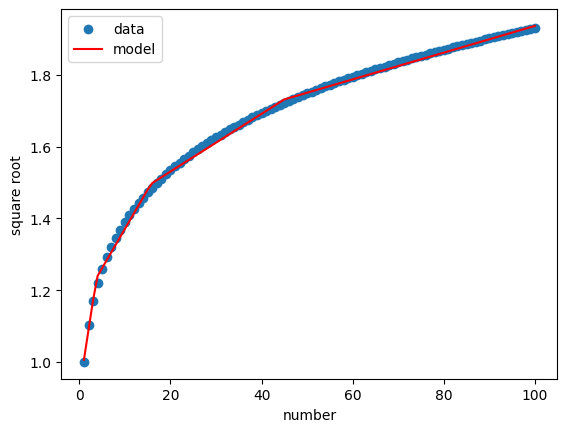

In [2]:
#Question 5

import tensorflow as tf
from numpy import loadtxt
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
from tensorflow.python.keras.optimizers import *
import numpy as np


#Load dataset
#split into input (X) and output (y)
#X = np.array([[1], [4], [9], [16], [25], [36], [49], [64], [81], [100]])
X = np.arange(1,101).reshape(-1,1)
X = X*1.0
#y = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = np.power(X,1/7)
y = y*1.0

#define keras model
model = Sequential()

model.add(Dense(6,input_dim=1,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(1))

#compile the keras model
opt = optimizers.Adam(learning_rate=0.001)
mse = tf.keras.losses.MeanSquaredError(
    reduction=tf.keras.losses.Reduction.SUM)
model.compile(loss=mse, optimizer=opt)



#fit the keras model on the dataset (CPU)
model.fit(X,y,epochs=2000,batch_size=10, verbose=0)
model.summary()

#make class predictions with the model
predictions = model.predict(X)

#summarize the first 10 cases
for i in range(10):
    print('%s => %.2f (expected %.2f)' %(X[i].tolist(), predictions[i], y[i]) )

import matplotlib.pyplot as plt
number_grid = np.linspace(1, 100, 100)
plt.scatter(X,y, label='data')
plt.plot(number_grid,model.predict(np.expand_dims(number_grid,axis=1)) , color='red', label='model')
plt.xlabel('number')
plt.ylabel('square root')
plt.legend()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 509 (1.99 KB)

 Trainable params: 169 (676.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 340 (1.33 KB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
5.1 => 2.22 (expected 1.40)
4.9 => 1.78 (expected 1.40)
4.7 => 1.34 (expected 1.30)
4.6 => 1.12 (expected 1.50)
5.0 => 2.00 (expected 1.40)
5.4 => 2.92 (expected 1.70)
4.6 => 1.12 (expected 1.40)
5.0 => 2.00 (expected 1.50)
4.4 => 0.68 (expected 1.40)
4.9 => 1.78 (expected 1.50)


/tmp/ipython-input-347917539.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('%s => %.2f (expected %.2f)' %(X[i].tolist(), predictions[i], y[i]) )


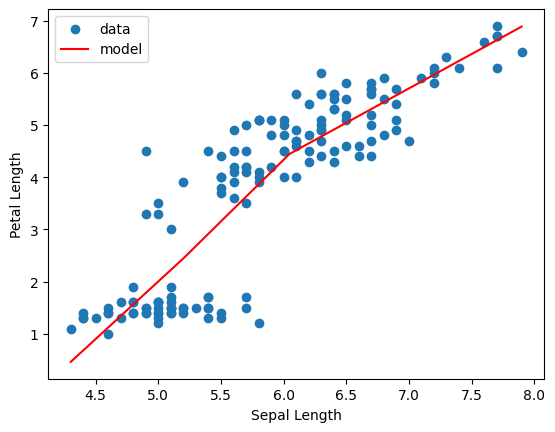

In [4]:
#Question 6
import tensorflow as tf
from numpy import loadtxt
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
from tensorflow.python.keras.optimizers import *
import numpy as np
from sklearn import datasets
iris = datasets.load_iris()
#print(iris)

#Load dataset
#split into input (X) and output (y)
#X = np.array([[1], [4], [9], [16], [25], [36], [49], [64], [81], [100]])
X = iris.data[:,0]
#X = X*1.0
#y = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = iris.data[:,2]
#y = y*1.0

#define keras model
model = Sequential()

model.add(Dense(8,input_dim=1,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1))

#compile the keras model
opt = optimizers.Adam(learning_rate=0.001)
mse = tf.keras.losses.MeanSquaredError(
    reduction=tf.keras.losses.Reduction.SUM)
model.compile(loss=mse, optimizer=opt)



#fit the keras model on the dataset (CPU)
model.fit(X,y,epochs=2000,batch_size=10, verbose=0)
model.summary()

#make class predictions with the model
predictions = model.predict(X)

#summarize the first 10 cases
for i in range(10):
    print('%s => %.2f (expected %.2f)' %(X[i].tolist(), predictions[i], y[i]) )


import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

number_grid = np.linspace(X.min(), X.max(), 100)
prediction_grid = model(number_grid, training=False).numpy()

plt.scatter(X, y, label='data')
plt.plot(number_grid, prediction_grid, color='red', label='model')
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.legend()